In [ ]:

from importlib import reload
import os
import sys
# Set up paths for utility imports
current_dir = os.getcwd()
utilities_dir = os.path.join(current_dir, '../../utils')

os.chdir(current_dir)
# Ensure the utilities directory is in the import path
if utilities_dir not in sys.path:
    sys.path.insert(0, utilities_dir)
    
import plotting   
 
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats import expon
from matplotlib.gridspec import GridSpec

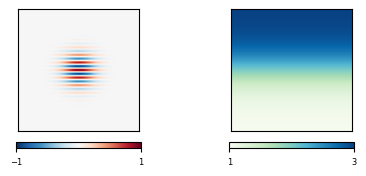

In [ ]:
# -------------------------
# Parameters
# -------------------------
alpha = 0.5
beta = 10
epsilon = 1

# -------------------------
# Domain
# -------------------------
x = np.linspace(-5, 5, 300)
y = np.linspace(-5, 5, 300)

X, Y = np.meshgrid(x, y)


# -------------------------
# Analytical solution
# -------------------------
U = np.exp(-alpha*(X**2 + Y**2)) * np.cos(beta*Y)


# -------------------------
# Variable coefficient
# -------------------------
K = 1 + 2/(1 + np.exp(-Y/epsilon))


# -------------------------
# Plot style
# -------------------------
fig, ax = plt.subplots(
    1, 2,
    figsize=(5.5, 2.2),
)


# Left: u(x,y)
im1 = ax[0].imshow(
    U,
    extent=[x.min(), x.max(), y.min(), y.max()],
    origin="lower",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    aspect="equal",
    rasterized=True
)

ax[0].set_xticks([])
ax[0].set_yticks([])

# for spine in ax[0].spines.values():
#     spine.set_linewidth(0.8)


# Right: k(y)
im2 = ax[1].imshow(
    K,
    extent=[x.min(), x.max(), y.min(), y.max()],
    origin="lower",
    cmap="GnBu",
    vmin=1,
    vmax=3,
    aspect="equal",
    rasterized=True
)

ax[1].set_xticks([])
ax[1].set_yticks([])

# for spine in ax[1].spines.values():
#     spine.set_linewidth(0.1)


# -------------------------
# Colorbars (horizontal)
# -------------------------
cbar1 = fig.colorbar(
    im1,
    ax=ax[0],
    orientation="horizontal",
    fraction=0.045,
    pad=0.08,
)

cbar2 = fig.colorbar(
    im2,
    ax=ax[1],
    orientation="horizontal",
    fraction=0.045,
    pad=0.08
)


# Small ticks like reference
cbar1.set_ticks([-1,1])
cbar2.set_ticks([1,3])

cbar1.ax.tick_params(labelsize=6)
cbar2.ax.tick_params(labelsize=6)


plt.subplots_adjust(
    wspace=0.0,
    bottom=0.25
)
plt.savefig("figures/infinite_analytical_sol.svg", bbox_inches="tight", dpi=300)
plt.show()

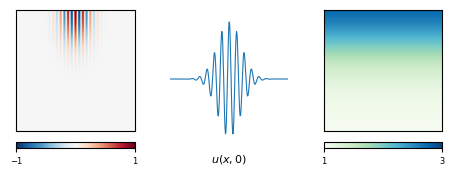

In [91]:
# -------------------------
# Parameters
# -------------------------
alpha = 0.5
beta = 10
epsilon = 0.75


# -------------------------
# Domain
# -------------------------
x = np.linspace(-5, 5, 300)
y = np.linspace(-5, 0, 300)

X, Y = np.meshgrid(x, y)


# -------------------------
# Analytical solution
# -------------------------
U = np.exp(-alpha*(X**2 + Y**2)) * np.cos(beta*X)


# -------------------------
# Boundary condition y=0
# -------------------------
u_boundary = np.exp(-alpha*x**2) * np.cos(beta*x)


# -------------------------
# Variable coefficient
# -------------------------
K = 1 + 2/(1 + np.exp(-(Y+1.5)/epsilon))


# -------------------------
# Figure
# -------------------------
fig, ax = plt.subplots(
    1, 3,
    figsize=(5.5, 2.2)
)


# =====================================================
# Solution u(x,y)
# =====================================================
im1 = ax[0].imshow(
    U,
    extent=[x.min(), x.max(), y.min(), y.max()],
    origin="lower",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    aspect="auto"
)

ax[0].set_xticks([])
ax[0].set_yticks([])

for s in ax[0].spines.values():
    s.set_linewidth(0.8)


# =====================================================
# Boundary condition
# =====================================================
ax[1].plot(
    x,
    u_boundary,
    linewidth=0.8
)

ax[1].text(
    0.5, -0.08,
    r"$u(x,0)$",
    transform=ax[1].transAxes,
    ha="center",
    va="center",
    fontsize=8
)
ax[1].set_xlim(-5,5)
ax[1].set_ylim(-1.2,1.2)

ax[1].set_xticks([])
ax[1].set_yticks([])

for s in ax[1].spines.values():
    s.set_visible(False)


# =====================================================
# Coefficient k(y)
# =====================================================
im2 = ax[2].imshow(
    K,
    extent=[x.min(), x.max(), y.min(), y.max()],
    origin="lower",
    cmap="GnBu",
    vmin=1,
    vmax=3,
    aspect="auto"
)

ax[2].set_xticks([])
ax[2].set_yticks([])

for s in ax[2].spines.values():
    s.set_linewidth(0.8)


# -------------------------
# Colorbars
# -------------------------
cbar1 = fig.colorbar(
    im1,
    ax=ax[0],
    orientation="horizontal",
    fraction=0.045,
    pad=0.08
)

cbar2 = fig.colorbar(
    im2,
    ax=ax[2],
    orientation="horizontal",
    fraction=0.045,
    pad=0.08
)


cbar1.set_ticks([-1,1])
cbar2.set_ticks([1,3])

cbar1.ax.tick_params(labelsize=6)
cbar2.ax.tick_params(labelsize=6)


# -------------------------
# Layout
# -------------------------
plt.subplots_adjust(
    wspace=0.3,
    bottom=0.25
)

plt.savefig("figures/semi_infinite_analytical_sol.svg", bbox_inches="tight", dpi=300)

plt.show()